#### OBJECTIVE: Which factors actually move the needle on sales? (Correlation)"

**DOMAIN**: Retail, Sales Forecasting

- Seasonality Discovery: We need to know if sales spike at specific times of the year, which would suggest we should add temporal features.
- Predictors for Sales: we need to find the correlation strength between features and target, to see which are important.
    This covers questions like
    - If Markdowns actually have a strong mathematical correlation to higher sales at the department level.
    - Macroeconomics (CPI & Unemployment): Do people buy less stuff when unemployment is high or CPI (inflation) is up?.
    - Does larger store size mean higher sales?.
    - And More...

**SUMMARY**:
- We can see higher sales in months of november and december due to year end festivities.
- There is a clear seasonal pattern that sales follow, peaks and troughs. Major peaks at year end.
- We should create separate features like `month`, `week_of_year` features to capture these trends.

- Aside from temporal features, `size` of the store is a strong predictor of sales this can serve as a strong baseline price for different types of stores.

- `markdown` showed low correlation, but this was due to sparsity of markdown as it was not recorded before 2011-11-04. After doing a correlation check on rows after 2011-11-04 ->
- markdown's have impact over the sales and it means more discount equals more sales however that would be dependent on other factors as well.
- `Cpi` and `Unemployment` correlation is very low and surprisingly minor negative.
- `Temperature` and `fuel` price have no effect on sales.

- **Multicollinearity** - markdown1 and markdown4 have a correlation of 0.82 which is high.

- `IsHoliday`- boxplot and summary metrics show that isholiday has a great impact, the sales are huge on holiday's compared to non holiday weeks.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

# Get the absolute path of the parent folder
parent_dir = str(Path().resolve().parent)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)


In [3]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import config
sns.set_theme()

In [4]:
sales_df = pl.read_delta(config.SILVER_SALES_PATH)
features_df = pl.read_delta(config.SILVER_FEATURES_PATH)
stores_df = pl.read_delta(config.SILVER_STORES_PATH)

In [11]:
master_df = sales_df.join(stores_df, on='store', how='left')
master_df = master_df.join(features_df, on=['store', 'date'])
master_df = master_df.drop('isholiday_right')
master_df.shape

(421570, 16)

Temporal patterns
- Is there any trend of sales over time(lets take month)

In [12]:
master_df.head()

store,dept,date,weekly_sales,isholiday,type,size,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment
i32,i32,date,f64,bool,str,i32,f64,f64,f32,f32,f32,f32,f32,f32,f32
1,1,2010-02-05,24924.5,false,"""A""",151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096359,8.106
1,2,2010-02-05,50605.27,false,"""A""",151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096359,8.106
1,3,2010-02-05,13740.12,false,"""A""",151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096359,8.106
1,4,2010-02-05,39954.04,false,"""A""",151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096359,8.106
1,5,2010-02-05,32229.38,false,"""A""",151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096359,8.106


In [7]:
master_df = master_df.with_columns(pl.col('date').dt.month().alias('month'))
monthly_sales = master_df.group_by('month').agg([pl.col('weekly_sales').mean().alias('monthly_sales')])
monthly_sales.head()

month,monthly_sales
i8,f64
7,15861.613997
11,17491.151001
9,15096.249922
6,16326.231156
4,15650.483663


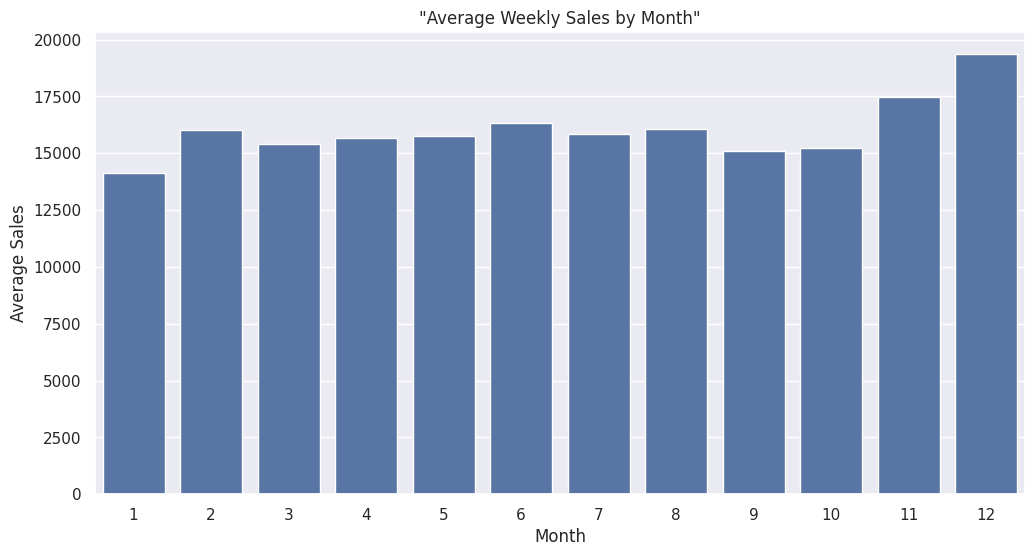

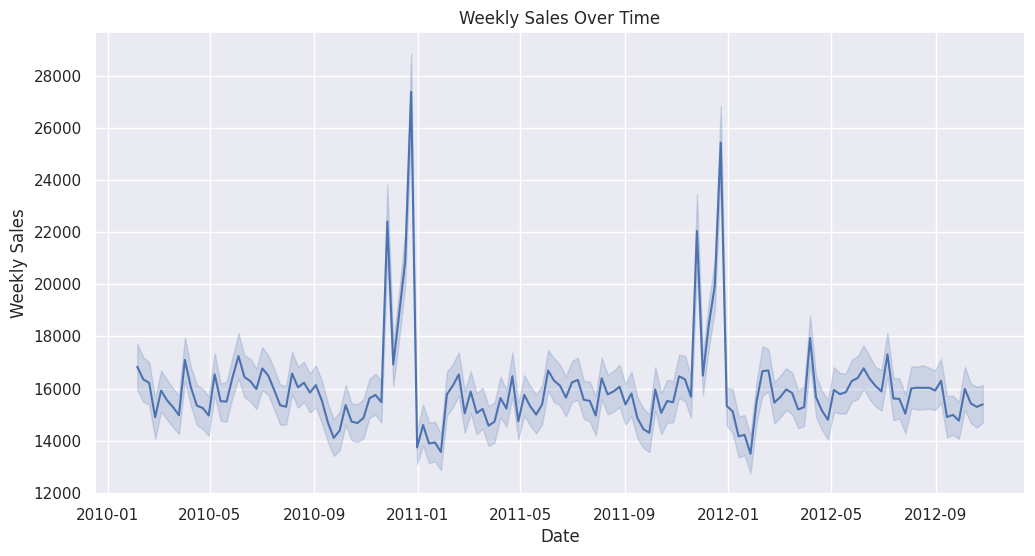

In [8]:

plt.figure(figsize=(12,6))
sns.barplot(data=monthly_sales, x='month', y='monthly_sales')
plt.title('"Average Weekly Sales by Month"')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.show()

plt.figure(figsize=(12,6))
sns.lineplot(data=master_df, x='date', y='weekly_sales')
plt.title('Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show()

**Correlation Between Variables**

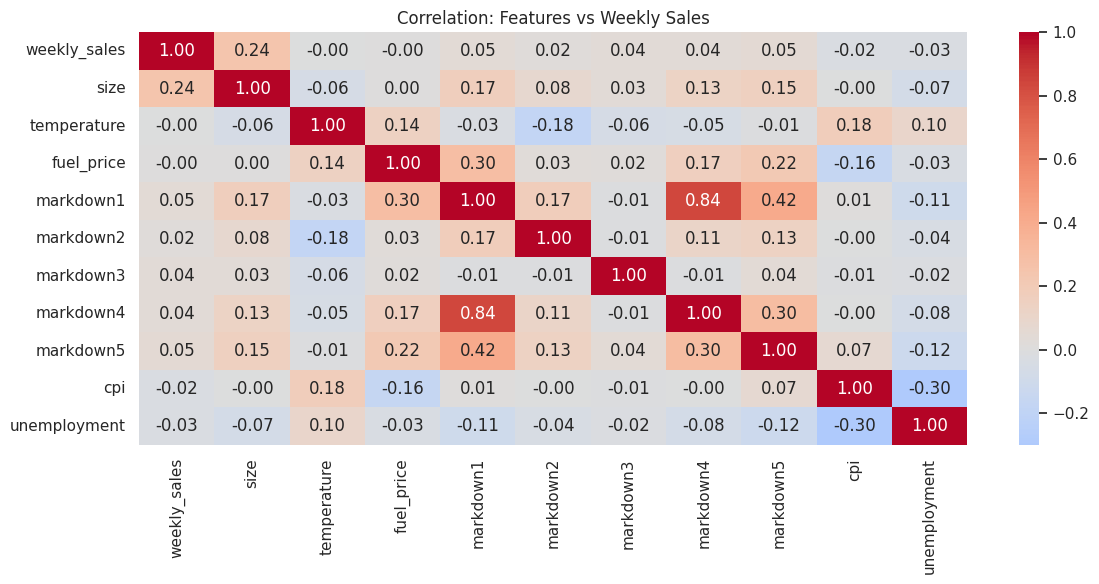

In [26]:
# Polars: Convert to Pandas OR compute corr properly
corr_df = master_df.select(numerical_cols).to_pandas().corr()

plt.figure(figsize=(12,6))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title("Correlation: Features vs Weekly Sales")
plt.tight_layout()
plt.show()

Post-2011 markdown1 corr:               weekly_sales  markdown1  markdown2  markdown3  markdown4  \
weekly_sales      1.000000   0.086428   0.032233   0.062100   0.061605   
markdown1         0.086428   1.000000   0.053537  -0.096950   0.822467   
markdown2         0.032233   0.053537   1.000000  -0.033334   0.030307   
markdown3         0.062100  -0.096950  -0.033334   1.000000  -0.058563   
markdown4         0.061605   0.822467   0.030307  -0.058563   1.000000   
markdown5         0.090362   0.162664   0.011760  -0.020394   0.136077   

              markdown5  
weekly_sales   0.090362  
markdown1      0.162664  
markdown2      0.011760  
markdown3     -0.020394  
markdown4      0.136077  
markdown5      1.000000  


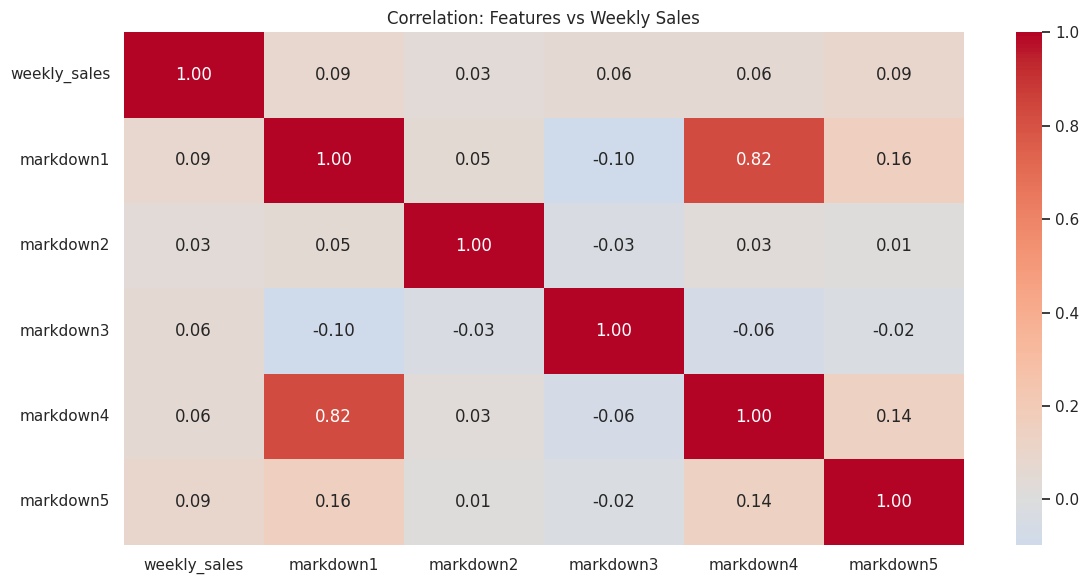

In [37]:
from datetime import date
# Post-2011 only correlation
post_2011 = master_df.filter(pl.col('date') > date(2011,11,4))
corr_markdown = post_2011.select(['weekly_sales','markdown1', 'markdown2', 'markdown3', 'markdown4','markdown5']).to_pandas().corr()
print("Post-2011 markdown1 corr:", corr_markdown)
plt.figure(figsize=(12,6))
sns.heatmap(corr_markdown, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title("Correlation: Features vs Weekly Sales")
plt.tight_layout()
plt.show()

**IsHoliday** - How much a holiday week contributes towards the sales

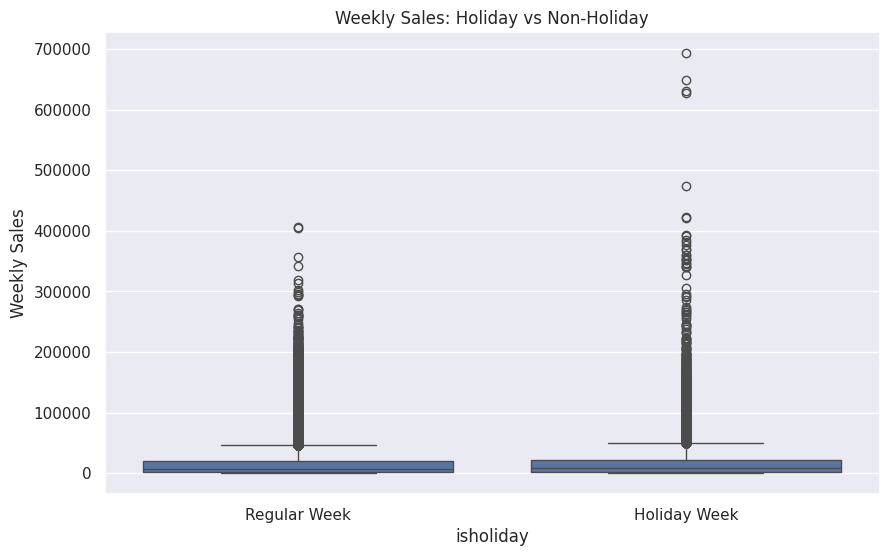

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=master_df.to_pandas(), x='isholiday', y='weekly_sales')
plt.title('Weekly Sales: Holiday vs Non-Holiday')
plt.ylabel('Weekly Sales')
plt.xticks([0,1], ['Regular Week', 'Holiday Week'])
plt.show()

In [47]:
holiday_stats = master_df.group_by('isholiday').agg([
    pl.col('weekly_sales').mean().alias('avg_sales'),
    pl.col('weekly_sales').median().alias('median_sales'),
    pl.col('weekly_sales').count().alias('week_count')
])

print(holiday_stats)
holiday_avg = holiday_stats.filter(pl.col('isholiday')==True)['avg_sales'][0]   # ~$35K
regular_avg = holiday_stats.filter(pl.col('isholiday')==False)['avg_sales'][0]  # ~$25K

lift_ratio = holiday_avg / regular_avg    # 35K / 25K = 1.40
holiday_lift_pct = (lift_ratio - 1) * 100 # (1.40 - 1) * 100 = 40%
print(f"Holiday sales lift: {holiday_lift_pct:.1f}%")

shape: (2, 4)
┌───────────┬──────────────┬──────────────┬────────────┐
│ isholiday ┆ avg_sales    ┆ median_sales ┆ week_count │
│ ---       ┆ ---          ┆ ---          ┆ ---        │
│ bool      ┆ f64          ┆ f64          ┆ u32        │
╞═══════════╪══════════════╪══════════════╪════════════╡
│ false     ┆ 15901.649652 ┆ 7589.95      ┆ 391909     │
│ true      ┆ 17036.092349 ┆ 7947.74      ┆ 29661      │
└───────────┴──────────────┴──────────────┴────────────┘
Holiday sales lift: 7.1%
